# 06 | Training Loop & Text Generation
## Sprint 6 — Day 3

**Previous notebook:** `05` — a complete tiny GPT with a working forward pass.
This is the final notebook. We train the model and watch it generate text.

---

We will train on a small text corpus (Shakespeare) using a standard
next-token prediction objective: given tokens `[t_0, t_1, ..., t_{n-1}]`,
predict `[t_1, t_2, ..., t_n]`. The loss is cross-entropy over the
vocabulary at every position.

The training loop is pure PyTorch — no Trainer, no callbacks, no abstractions.
After training we will sample from the model autoregressively and visualise
what it learned to attend to.

---

**By the end of this notebook you will have:**
- Implemented cross-entropy loss for language modelling
- Written a complete PyTorch training loop from scratch
- Trained the tiny GPT on a real text corpus
- Generated text from the trained model
- Plotted the training loss curve and visualised learned attention patterns

---

*This is the final notebook. You have built a Transformer from scratch.*

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import os

torch.manual_seed(42)

d_model     = 64
num_heads   = 8
d_ff        = 256
num_blocks  = 4
max_seq_len = 128
batch_size  = 16
seq_len     = 64
lr          = 3e-4
num_steps   = 3000

def positional_encoding(max_seq_len, d_model):
    PE = torch.zeros(max_seq_len, d_model)
    position = torch.arange(0, max_seq_len).unsqueeze(1).float()
    div_term = torch.pow(10000.0, torch.arange(0, d_model, 2).float() / d_model)
    PE[:, 0::2] = torch.sin(position / div_term)
    PE[:, 1::2] = torch.cos(position / div_term)
    return PE

class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(max_seq_len, d_model)
    def forward(self, x):
        return self.embedding(x) + self.pe[:x.shape[1], :]

class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
        self.eps   = eps
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std  = x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x)))

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
    def make_causal_mask(self, T):
        return torch.tril(torch.ones(T, T))
    def forward(self, x):
        B, T, _ = x.shape
        Q = self.W_Q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        mask = self.make_causal_mask(T)
        attn_out, weights = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_O(attn_out), weights

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ff        = FeedForward(d_model, d_ff)
        self.norm1     = LayerNorm(d_model)
        self.norm2     = LayerNorm(d_model)
    def forward(self, x):
        attn_out, weights = self.attention(x)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x, weights

class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_blocks, max_seq_len):
        super().__init__()
        self.embedding = InputEmbedding(vocab_size, d_model, max_seq_len)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff)
            for _ in range(num_blocks)
        ])
        self.norm    = LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
    def forward(self, x):
        x = self.embedding(x)
        all_weights = []
        for block in self.blocks:
            x, weights = block(x)
            all_weights.append(weights)
        x = self.norm(x)
        return self.lm_head(x), all_weights

print("All components loaded.")

All components loaded.


**LOAD AND TOKENIZE *"SHAKESPEARE"***

In [2]:
url  = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
path = "../shakespeare.txt"

if not os.path.exists(path):
    urllib.request.urlretrieve(url, path)
    print("Downloaded shakespeare.txt")
else:
    print("shakespeare.txt already exists")

with open(path, "r") as f:
    text = f.read()

chars    = sorted(set(text))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [char_to_idx[c] for c in s]
decode = lambda l: "".join([idx_to_char[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data   = data[split:]

print(f"Corpus length:  {len(text):,} characters")
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Training tokens: {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")
print(f"Sample vocab: {chars[:20]}")
print(f"Expected initial loss: {torch.log(torch.tensor(float(vocab_size))):.4f}")

Downloaded shakespeare.txt
Corpus length:  1,115,394 characters
Vocabulary size: 65 unique characters
Training tokens: 1,003,854
Validation tokens: 111,540
Sample vocab: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Expected initial loss: 4.1744


**BATCH SAMPLER**

In [3]:
def get_batch(data, batch_size, seq_len):
    ix = torch.randint(0, len(data) - seq_len - 1, (batch_size,))
    x  = torch.stack([data[i:i + seq_len] for i in ix])
    y  = torch.stack([data[i + 1:i + seq_len + 1] for i in ix])
    return x, y

x_sample, y_sample = get_batch(train_data, batch_size, seq_len)
print(f"Input batch shape:  {x_sample.shape}")
print(f"Target batch shape: {y_sample.shape}")
print(f"\nSample input  (decoded): '{decode(x_sample[0].tolist()[:30])}'")
print(f"Sample target (decoded): '{decode(y_sample[0].tolist()[:30])}'")

Input batch shape:  torch.Size([16, 64])
Target batch shape: torch.Size([16, 64])

Sample input  (decoded): 'd, lips, O you
The doors of br'
Sample target (decoded): ', lips, O you
The doors of bre'


**TRAINING LOOP**

In [4]:
model     = GPT(vocab_size, d_model, num_heads, d_ff, num_blocks, max_seq_len)
optimiser = torch.optim.Adam(model.parameters(), lr=lr)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Starting training for {num_steps} steps...\n")

train_losses = []
log_every    = 100

for step in range(num_steps):
    x, y = get_batch(train_data, batch_size, seq_len)

    logits, _ = model(x)

    loss = F.cross_entropy(
        logits.view(-1, vocab_size),
        y.view(-1)
    )

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    train_losses.append(loss.item())

    if step % log_every == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.4f}")

print(f"\nFinal loss: {train_losses[-1]:.4f}")

Model parameters: 207,360
Starting training for 3000 steps...

Step    0 | Loss: 4.3139
Step  100 | Loss: 2.8154
Step  200 | Loss: 2.5985
Step  300 | Loss: 2.6091
Step  400 | Loss: 2.4721
Step  500 | Loss: 2.4032
Step  600 | Loss: 2.4384
Step  700 | Loss: 2.4286
Step  800 | Loss: 2.3544
Step  900 | Loss: 2.2872
Step 1000 | Loss: 2.2710
Step 1100 | Loss: 2.2830
Step 1200 | Loss: 2.1577
Step 1300 | Loss: 2.2007
Step 1400 | Loss: 2.1468
Step 1500 | Loss: 2.1943
Step 1600 | Loss: 2.0906
Step 1700 | Loss: 2.1060
Step 1800 | Loss: 2.0970
Step 1900 | Loss: 2.0991
Step 2000 | Loss: 2.1138
Step 2100 | Loss: 2.0088
Step 2200 | Loss: 2.0317
Step 2300 | Loss: 1.9899
Step 2400 | Loss: 1.9658
Step 2500 | Loss: 1.9184
Step 2600 | Loss: 1.8843
Step 2700 | Loss: 1.9712
Step 2800 | Loss: 1.8886
Step 2900 | Loss: 1.9354

Final loss: 1.9924


**PLOTTING LOST CURVE**

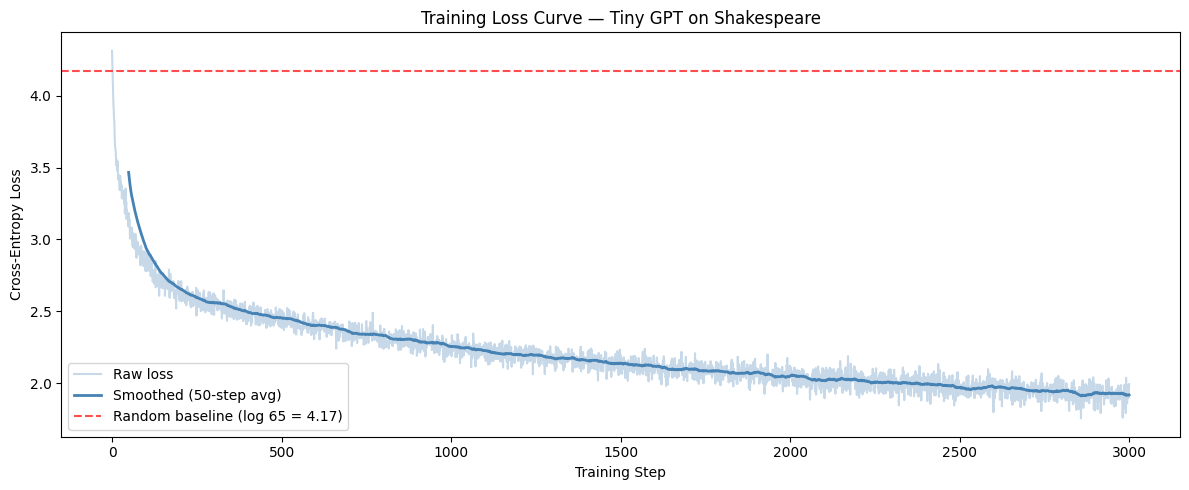

In [5]:
smoothed = np.convolve(train_losses, np.ones(50)/50, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(train_losses, alpha=0.3, color='steelblue', label='Raw loss')
plt.plot(range(49, len(train_losses)), smoothed, color='steelblue', linewidth=2, label='Smoothed (50-step avg)')
plt.axhline(y=np.log(vocab_size), color='red', linestyle='--', alpha=0.7, label=f'Random baseline (log {vocab_size} = {np.log(vocab_size):.2f})')
plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss Curve — Tiny GPT on Shakespeare')
plt.legend()
plt.tight_layout()
plt.show()

**TEXT GENERATION**

In [6]:
def generate(model, seed_text, max_new_tokens, temperature=0.8):
    model.eval()
    tokens = encode(seed_text)
    tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            tokens_cropped = tokens[:, -max_seq_len:]
            logits, _      = model(tokens_cropped)
            next_logits    = logits[0, -1, :]
            next_logits    = next_logits / temperature
            probs          = F.softmax(next_logits, dim=-1)
            next_token     = torch.multinomial(probs, num_samples=1)
            tokens         = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

    model.train()
    return decode(tokens[0].tolist())

output = generate(model, seed_text="KING:", max_new_tokens=300, temperature=0.8)
print(output)

KING:
Shave be death, from thou the streelve' on that
Whis be do haven p marind merne bure he waman hame belmenimacknnnpth t s ithadenghit in.
Ar y h wn hendr ith he me st illllllld in rch t lllchmmer, ha in megZucre wicht pee t t t t s;
Hevenke t, he be wn dr. we an ilchenthoman mun lenonccheyown muchea


**VISUALIZING TRAINED ATTENTION PATTERNS**

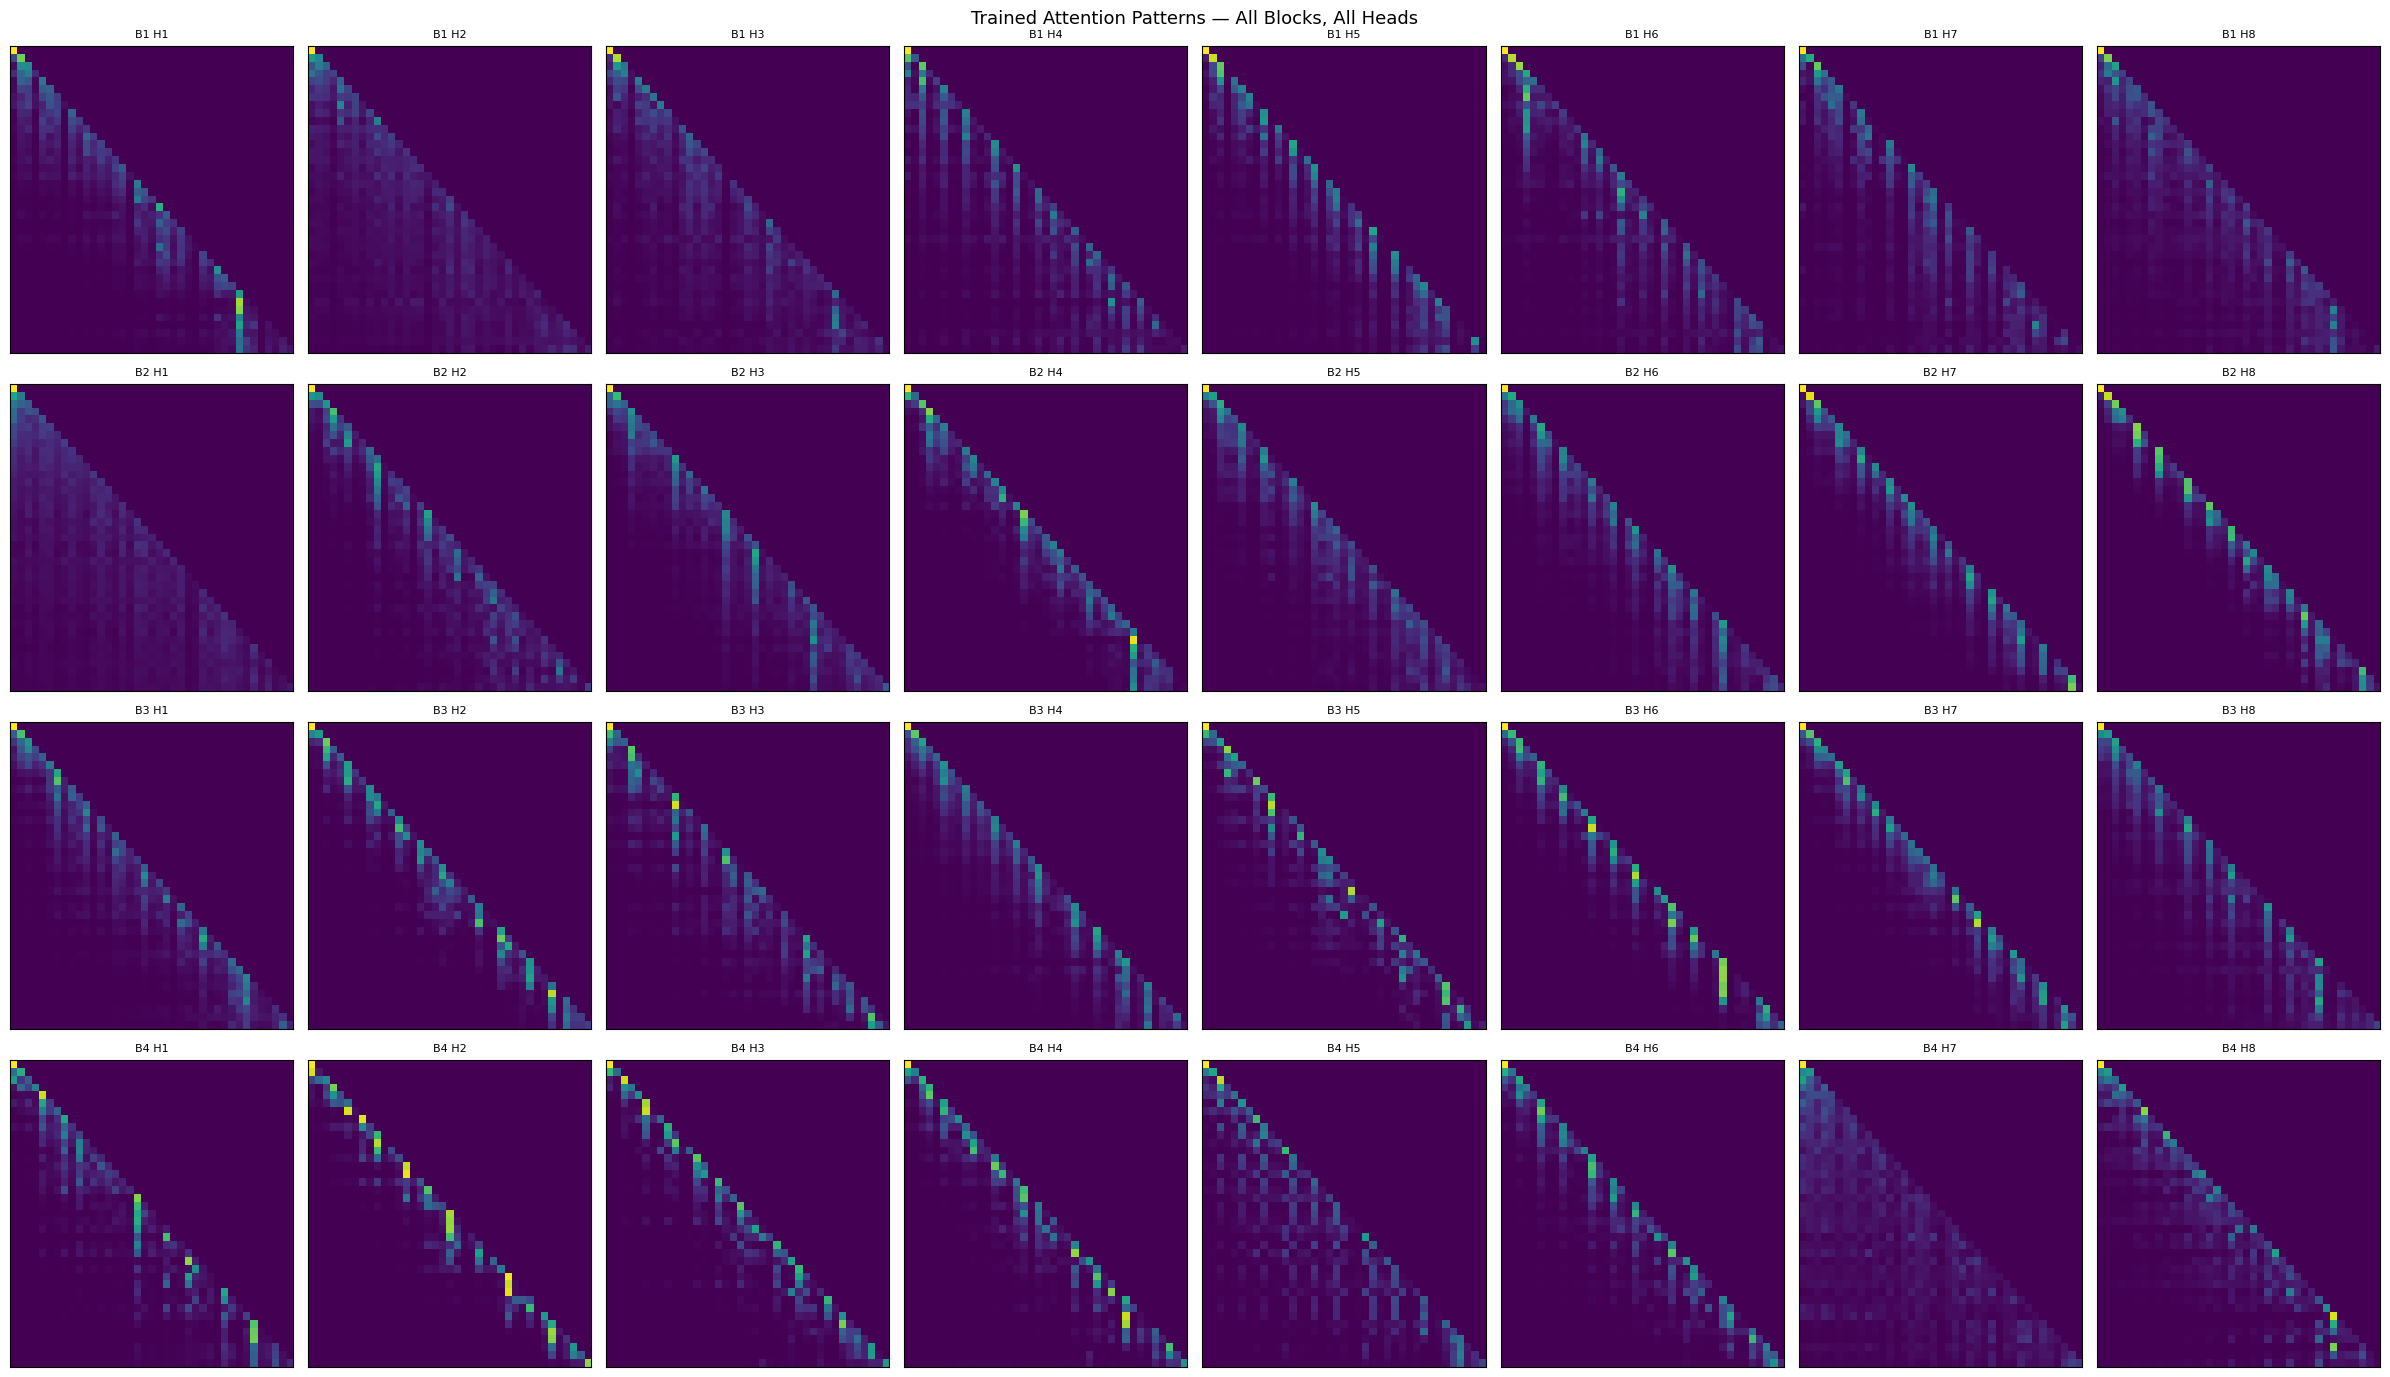

In [7]:
model.eval()
sample_text    = "To be or not to be that is the question"
sample_tokens  = torch.tensor(encode(sample_text), dtype=torch.long).unsqueeze(0)

with torch.no_grad():
    _, all_weights = model(sample_tokens)

fig, axes = plt.subplots(num_blocks, num_heads, figsize=(24, 14))

for block_idx in range(num_blocks):
    for head_idx in range(num_heads):
        ax = axes[block_idx, head_idx]
        w  = all_weights[block_idx][0, head_idx].numpy()
        im = ax.imshow(w, cmap='viridis', aspect='auto', vmin=0, vmax=1)
        ax.set_title(f'B{block_idx+1} H{head_idx+1}', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Trained Attention Patterns — All Blocks, All Heads', fontsize=13)
plt.tight_layout()
plt.show()

**COMPARING GENERATION AT DIFFERENT TEMPERATURES**

In [8]:
for temp in [0.5, 0.8, 1.2]:
    print(f"\n{'='*50}")
    print(f"Temperature: {temp}")
    print('='*50)
    output = generate(model, seed_text="KING:", max_new_tokens=150, temperature=temp)
    print(output)


Temperature: 0.5
KING:
By best for me which great and end thing my are
That shall om han weime m an s yowerrurrrustwan thumellllllllllllllllllllllllllllllllllllllllld t t t

Temperature: 0.8
KING:
My, dise, parrd of of then and me, her seen in ome
po this our um the it be t wa we ben druchemen chexcheenf henithen the sthuppllellllo t; y s?e w, 

Temperature: 1.2
KING:
May lor beattion.

My LBORD BENCHAP, RFry:
Bard'de my sorn, f fffeoarahourur, Haghr I muzelubpall?ptrOLomppbabpmen tan ump thtiizownvonqUdeethnwe? wi
